Shape: (2520798, 71)
Data Types:
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 71, dtype: object
Missing Values:
Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 71, dtype: int64
Duplicate Rows: 0
Unique Values:
Destination Port                 53791
Flow Duration                  10508

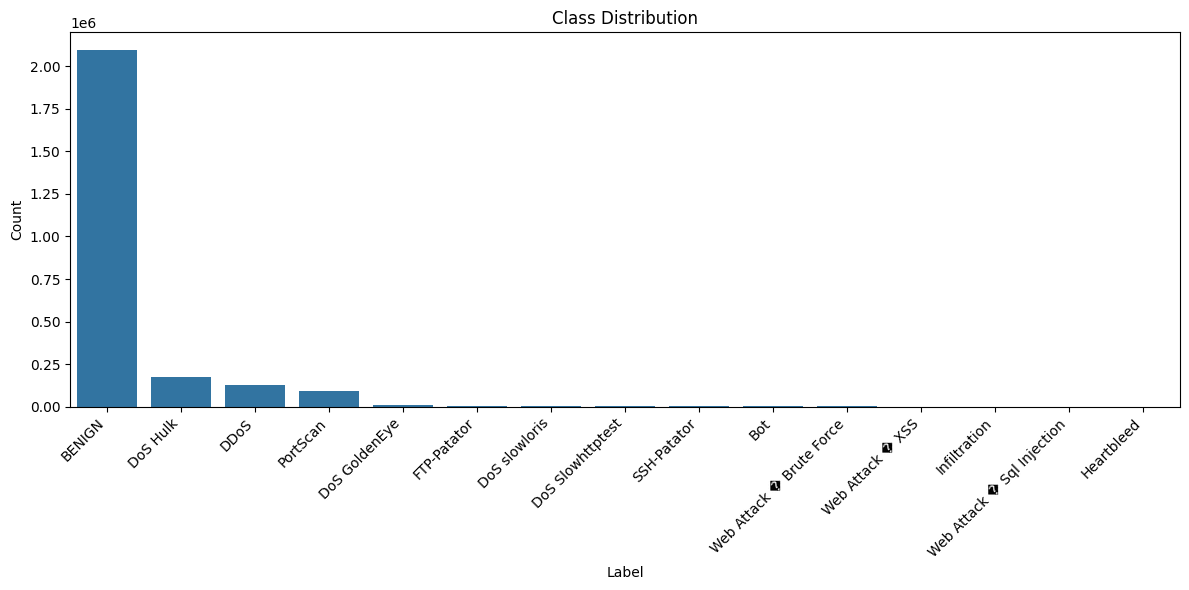

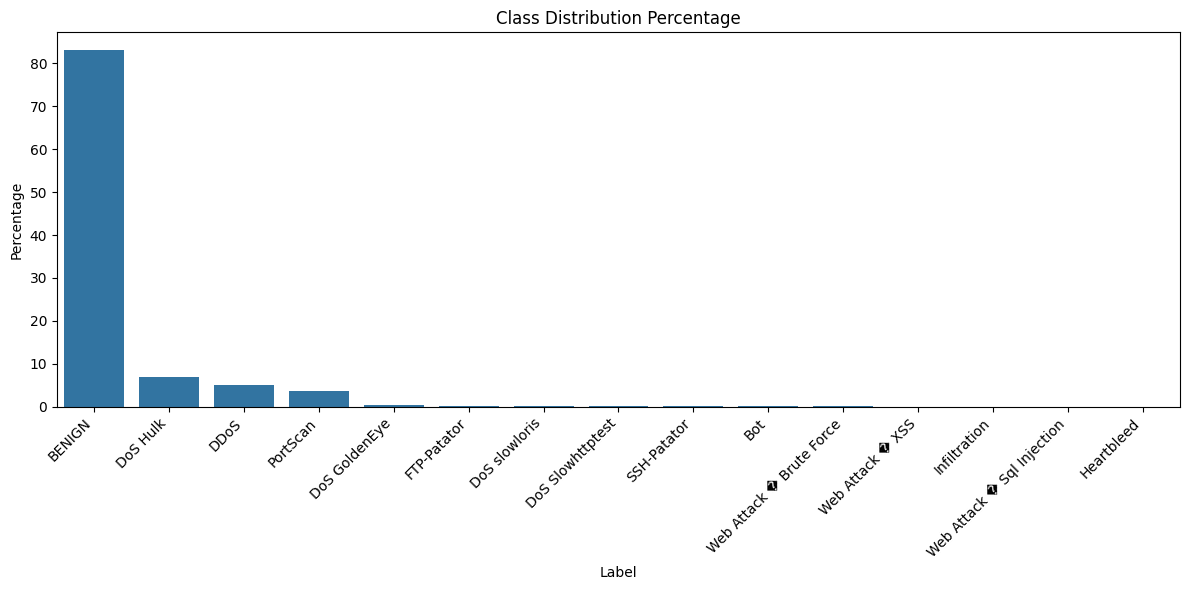

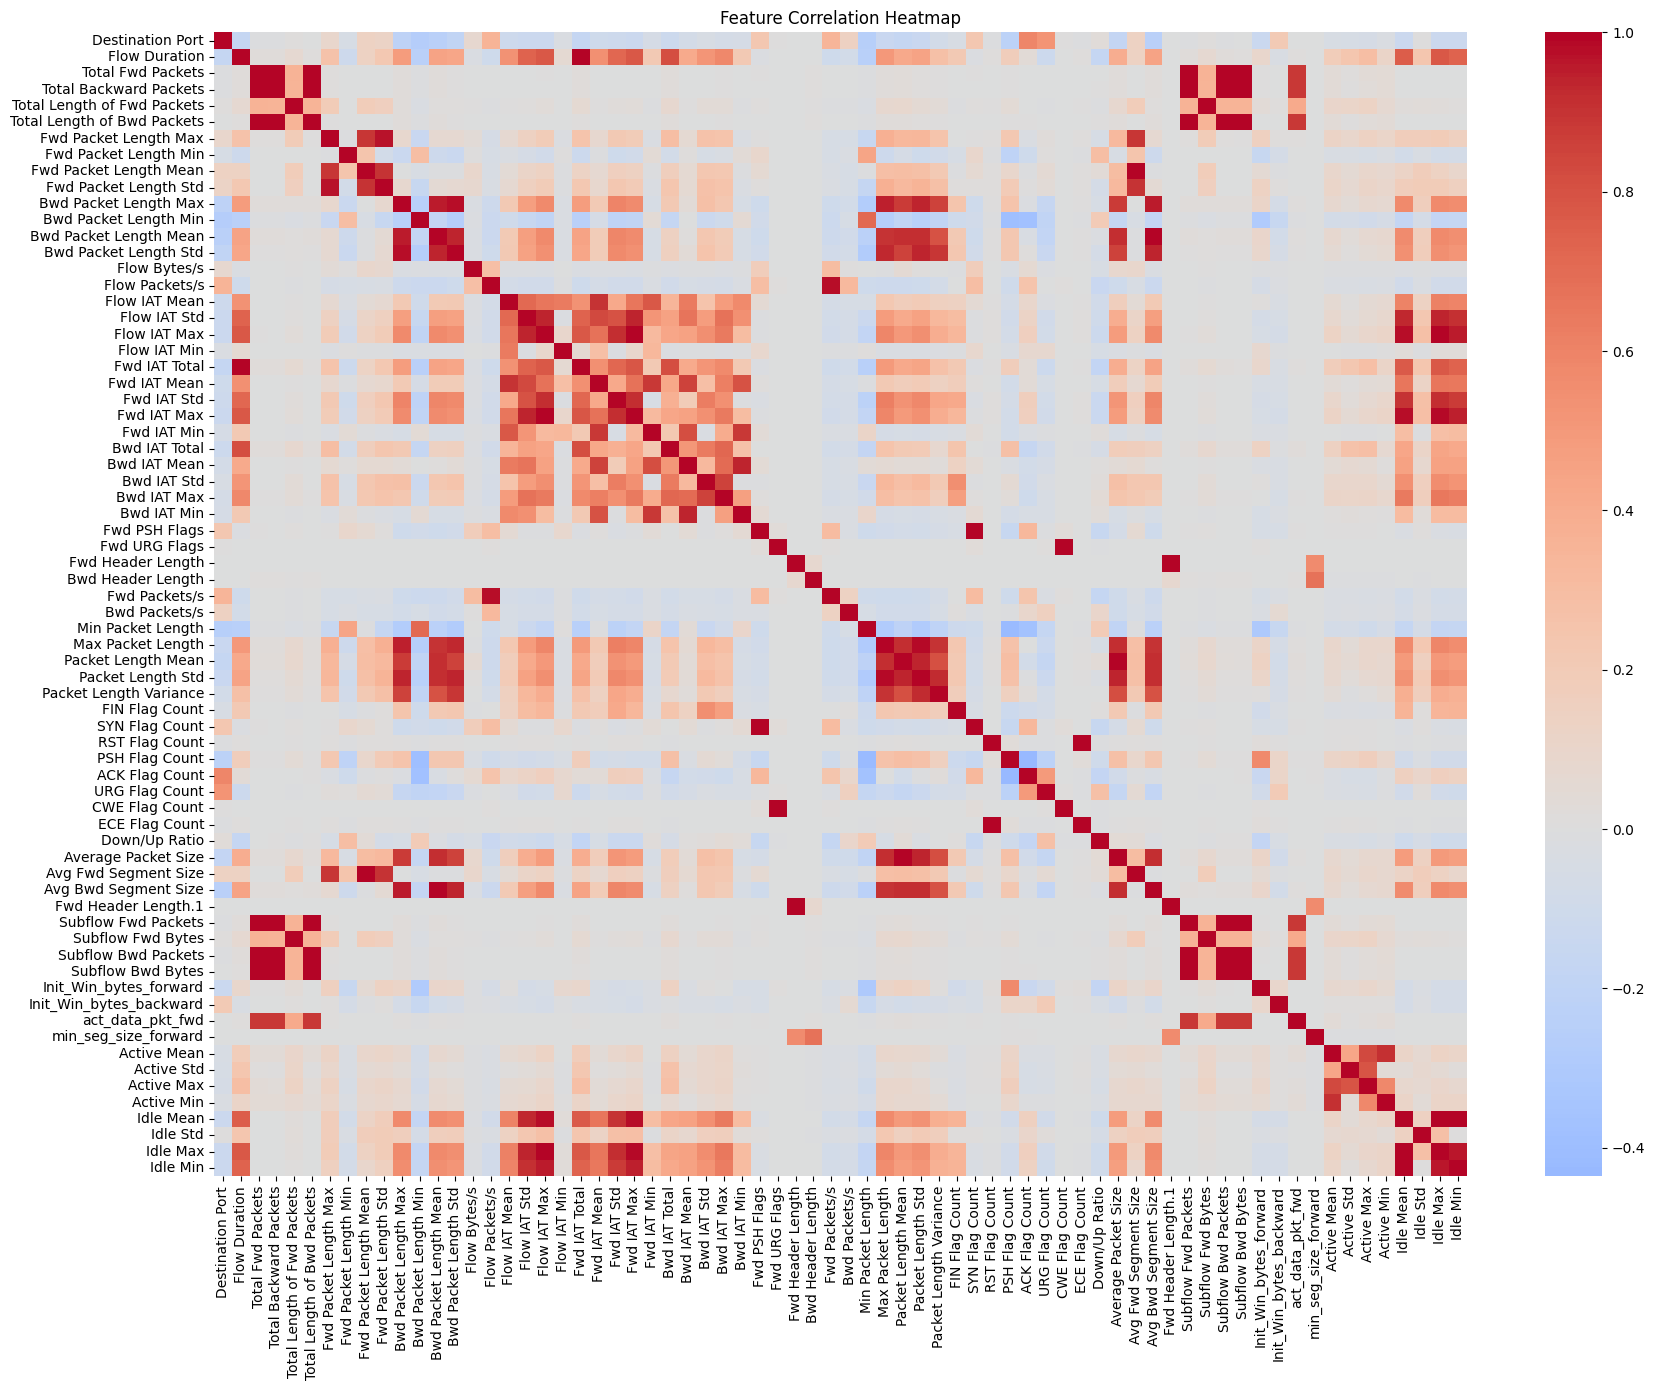


Highly Correlated Features:
                    Feature 1             Feature 2  Correlation
801   Bwd Packet Length Mean  Avg Bwd Segment Size     1.000000
1689           Fwd URG Flags        CWE Flag Count     1.000000
188        Total Fwd Packets   Subflow Fwd Packets     1.000000
1646           Fwd PSH Flags        SYN Flag Count     1.000000
566   Fwd Packet Length Mean  Avg Fwd Segment Size     1.000000
...                      ...                   ...          ...
2389             Active Mean            Active Min     0.905749
1330             Fwd IAT Std             Idle Mean     0.903174
786   Bwd Packet Length Mean     Max Packet Length     0.903076
1901       Max Packet Length  Avg Bwd Segment Size     0.903076
988            Flow IAT Mean          Fwd IAT Mean     0.901873

[71 rows x 3 columns]

Zero Variance Features:
 []


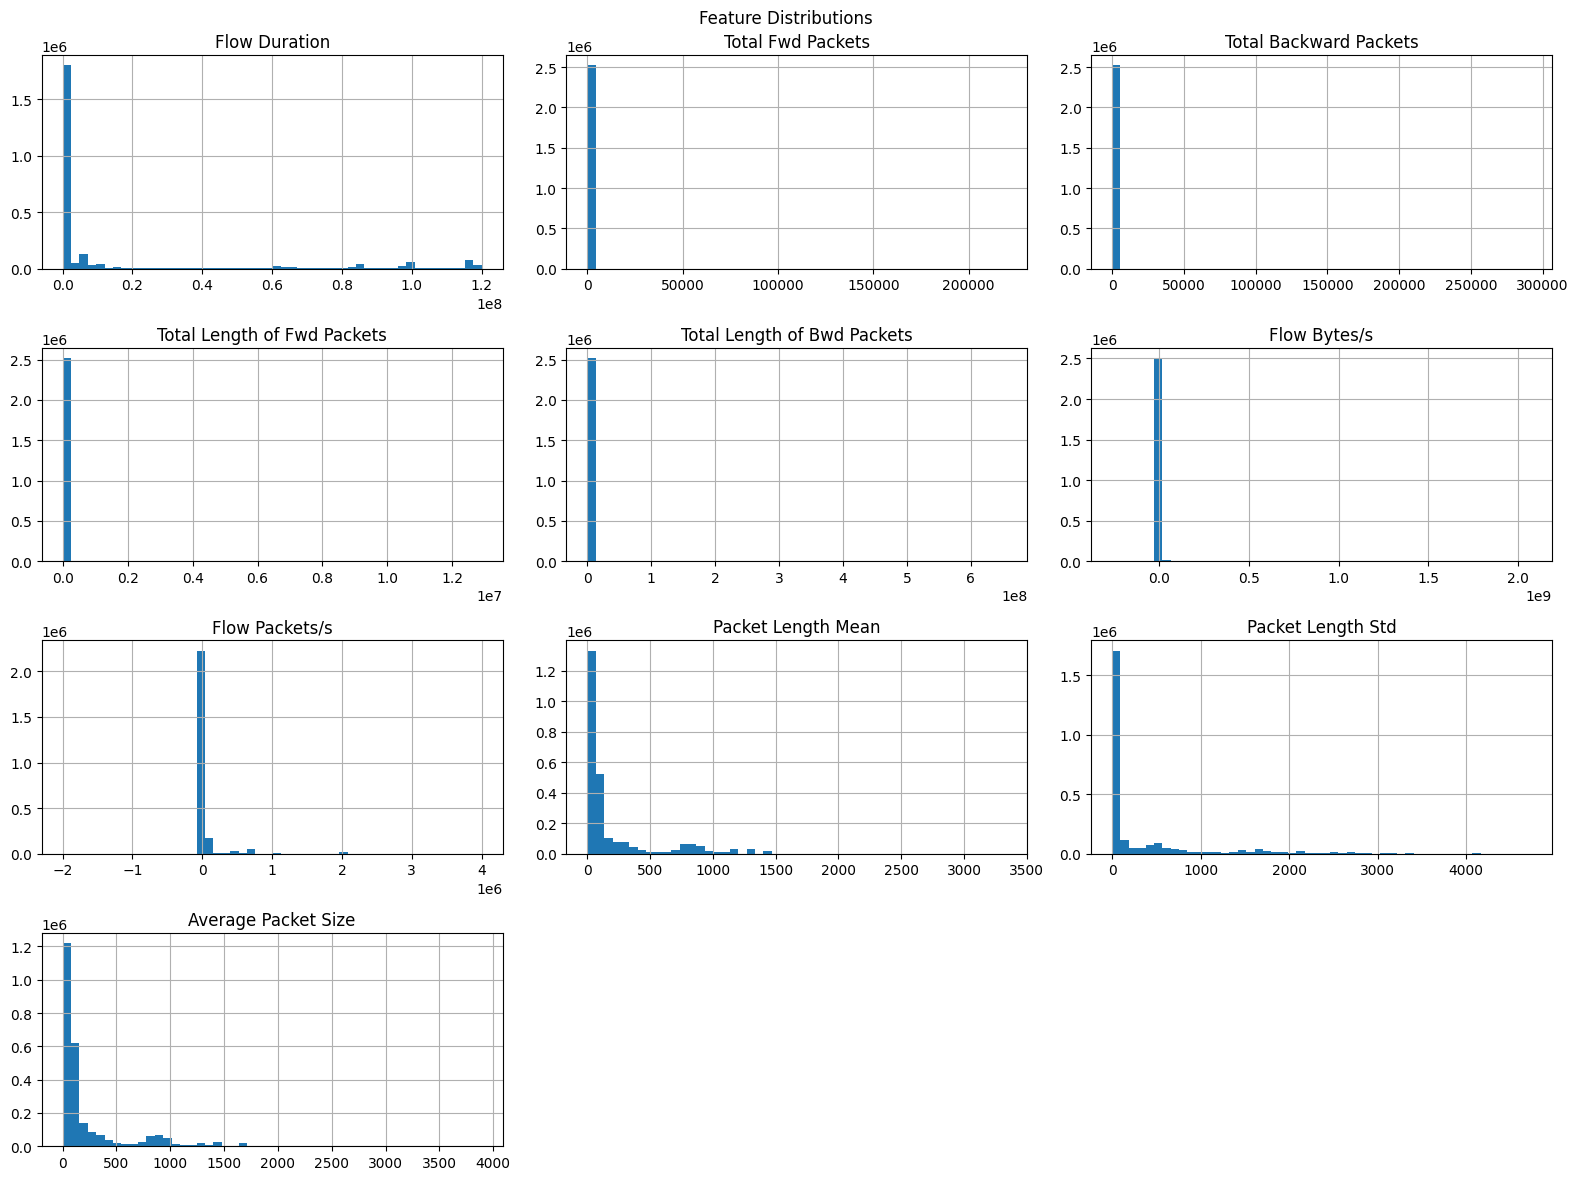

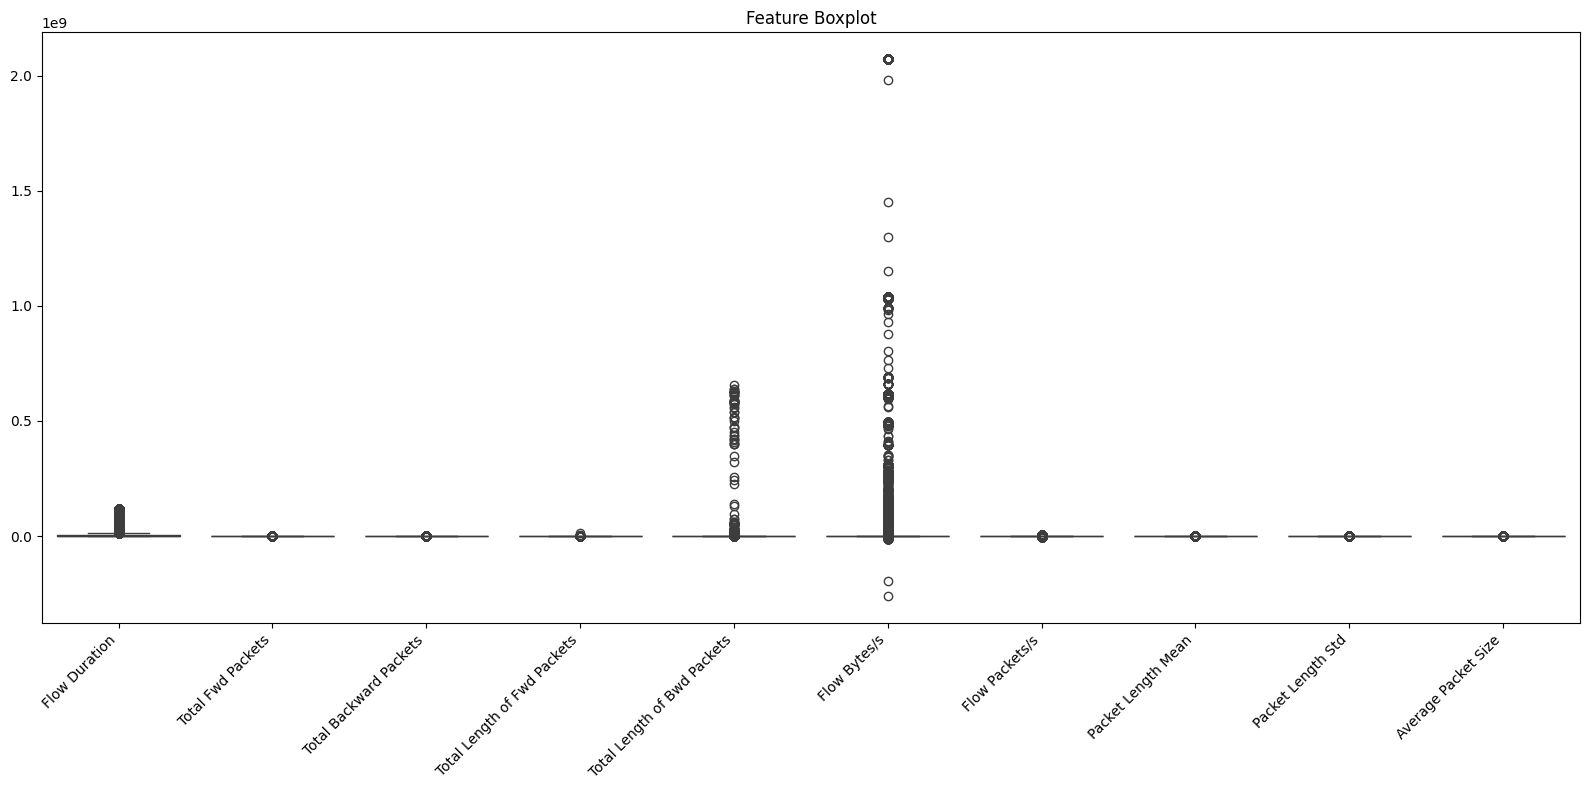


Feature Skewness:
 Total Length of Fwd Packets     760.581442
Subflow Fwd Bytes               758.720646
act_data_pkt_fwd                268.563578
Subflow Bwd Packets             230.896626
Total Backward Packets          230.896626
                                  ...     
ACK Flag Count                    0.812195
min_seg_size_forward           -447.802984
Bwd Header Length              -676.638638
Fwd Header Length             -1250.428527
Fwd Header Length.1           -1250.428527
Length: 70, dtype: float64


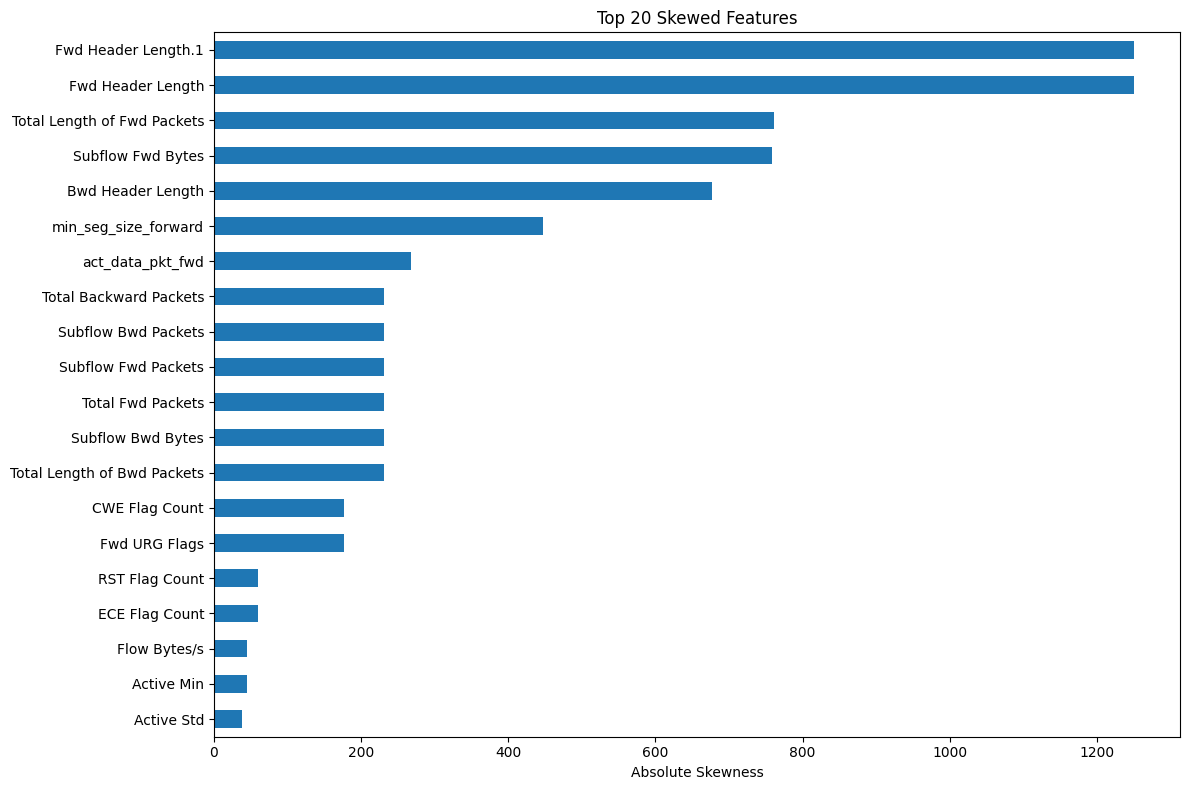

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\ARYAN MAHAKUR\Desktop\VS CODE\SAFEDEV.AI\ProcessedDataSet.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)

print("Data Types:")
print(df.dtypes)

print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

print("Unique Values:")
print(df.nunique())

print("Statistics:")
print(df.describe())

print("Infinite Values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum())

print("Label Distribution:")
print(df["Label"].value_counts())

print("Label Percentage:")
print(df["Label"].value_counts(normalize=True) * 100)
# Class distribution

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Label", order=df["Label"].value_counts().index)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Class distribution percentage

label_percent = df["Label"].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=label_percent.index, y=label_percent.values)
plt.title("Class Distribution Percentage")
plt.xlabel("Label")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Correlation matrix

X = df.drop(columns=["Label"])

corr = X.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


# Highly correlated features

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "Feature 1",
        "level_1": "Feature 2",
        0: "Correlation"
    })
)

high_corr = high_corr[high_corr["Correlation"] >= 0.90]
high_corr = high_corr.sort_values("Correlation", ascending=False)

print("\nHighly Correlated Features:\n", high_corr)


# Zero variance features

zero_variance = X.columns[X.nunique() <= 1]

print("\nZero Variance Features:\n", zero_variance.tolist())


# Feature distributions

features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size"
]

df[features].hist(figsize=(16, 12), bins=50)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()


# Boxplot

plt.figure(figsize=(16, 8))
sns.boxplot(data=df[features])
plt.title("Feature Boxplot")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Skewness

skewness = X.skew().sort_values(ascending=False)

print("\nFeature Skewness:\n", skewness)


# Top skewed features

plt.figure(figsize=(12, 8))
skewness.abs().sort_values(ascending=False).head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Skewed Features")
plt.xlabel("Absolute Skewness")
plt.tight_layout()
plt.show()